<a href="https://colab.research.google.com/github/tezendrax/Machine-Learning-Prac/blob/main/Bias_and_Variance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

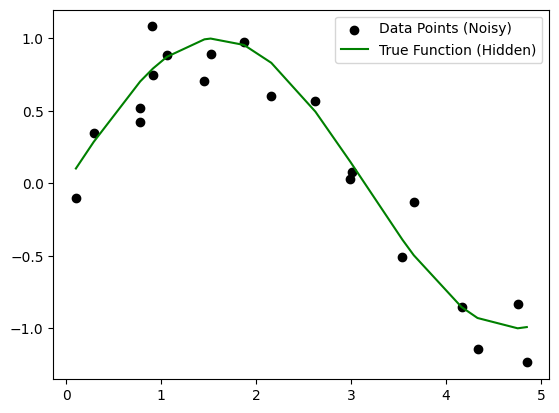

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1) random data
np.random.seed(42)
x = np.sort(np.random.rand(20) * 5) # 20 points between 0 and 5
y_true = np.sin(x)
y_noise = y_true + np.random.normal(0, 0.2, len(x)) # Adding some "messiness"

# 2) Plot it
plt.scatter(x, y_noise, color='black', label='Data Points (Noisy)')
plt.plot(x, y_true, color='green', label='True Function (Hidden)')
plt.legend()
plt.show()



Degree 1 weights (first 3): [-0.37707276  1.01609441]
Degree 4 weights (first 3): [ 0.00840349 -0.00335164 -0.52544481]
Degree 15 weights (first 3): [ 0.00185051 -0.06427686  1.02560019]




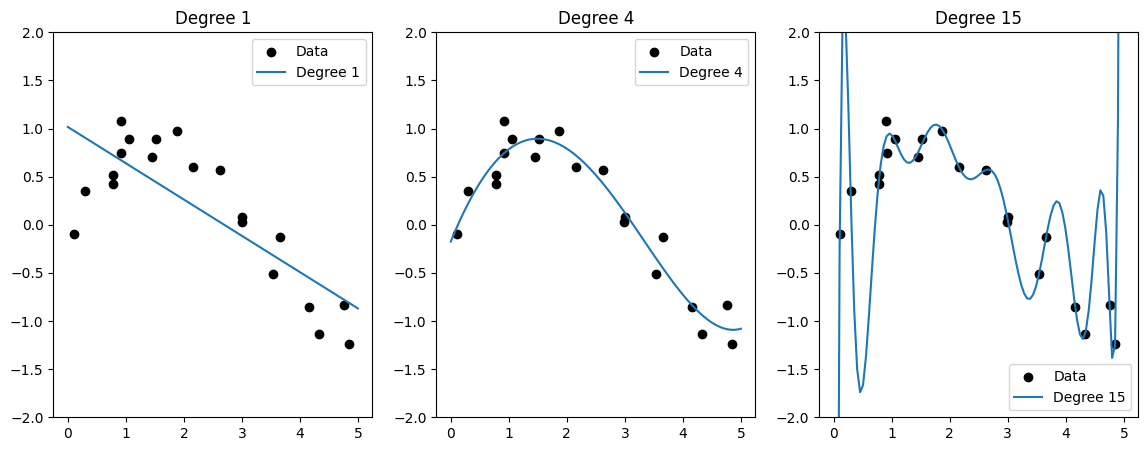

In [ ]:
# 3) model training stage
degrees = [1, 4, 15]
plt.figure(figsize=(14, 5))

for i, degree in enumerate(degrees):
    ax = plt.subplot(1, len(degrees), i + 1)

    # training the model (tooo find the weights)
    weights = np.polyfit(x, y_noise, degree)
    model = np.poly1d(weights)

    # plotting
    x_range = np.linspace(0, 5, 100)
    plt.scatter(x, y_noise, color='black', label="Data")
    plt.plot(x_range, model(x_range), label=f"Degree {degree}")

    plt.title(f"Degree {degree}")
    plt.ylim(-2, 2)
    plt.legend()

    # printing the weights to see them explode
    print(f"Degree {degree} weights (first 3): {weights[:3]}")
print("\n")
plt.show()

In [ ]:
# 4) relation b/w degree and magnitude
for deg in [1, 4, 15]:
    weights = np.polyfit(x, y_noise, deg)
    max_w = np.max(np.abs(weights))
    print(f"Degree {deg} -> maxx weight magnitude: {max_w:.2f}")

Degree 1 -> maxx weight magnitude: 1.02
Degree 4 -> maxx weight magnitude: 1.48
Degree 15 -> maxx weight magnitude: 16413.26


In [ ]:
from sklearn.metrics import mean_squared_error

for deg in [1, 4, 15]:
    weights = np.polyfit(x, y_noise, deg)
    model = np.poly1d(weights)

    # calculate error between predicted and actual noisy dots
    predictions = model(x)
    mse = mean_squared_error(y_noise, predictions)
    print(f"Degree {deg} Err: {mse:.4f}")

Degree 1 Err: 0.1852
Degree 4 Err: 0.0291
Degree 15 Err: 0.0036


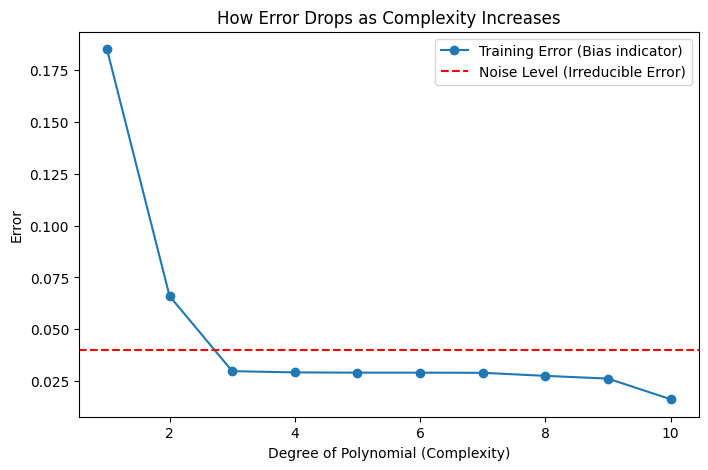

In [ ]:
degrees = range(1, 11)
train_errors = []

for deg in degrees:
    # train model
    weights = np.polyfit(x, y_noise, deg)
    model = np.poly1d(weights)

    # calculate mean squared error
    pred = model(x)
    mse = np.mean((y_noise - pred)**2)
    train_errors.append(mse)

# plotting the error eurve
plt.figure(figsize=(8, 5))
plt.plot(degrees, train_errors, marker='o', label='Training Error (Bias indicator)')
plt.axhline(y=0.04, color='r', linestyle='--', label='Noise Level (Irreducible Error)')
plt.xlabel('Degree of Polynomial (Complexity)')
plt.ylabel('Error')
plt.title('How Error Drops as Complexity Increases')
plt.legend()
plt.show()